Found 26 calibration images
Processing...
  Image 01: SUCCESS - corners detected
  Image 02: SUCCESS - corners detected
  Image 03: SUCCESS - corners detected
  Image 04: SUCCESS - corners detected
  Image 05: SUCCESS - corners detected
  Image 06: FAILED  - corners not found (IMG_20260611_124105_505.jpg)
  Image 07: SUCCESS - corners detected
  Image 08: SUCCESS - corners detected
  Image 09: SUCCESS - corners detected
  Image 10: FAILED  - corners not found (IMG_20260611_124113_097.jpg)
  Image 11: SUCCESS - corners detected
  Image 12: FAILED  - corners not found (IMG_20260611_124123_031.jpg)
  Image 13: SUCCESS - corners detected
  Image 14: FAILED  - corners not found (IMG_20260611_124130_170.jpg)
  Image 15: FAILED  - corners not found (IMG_20260611_124132_043.jpg)
  Image 16: FAILED  - corners not found (IMG_20260611_124140_472.jpg)
  Image 17: FAILED  - corners not found (IMG_20260611_124143_410.jpg)
  Image 18: SUCCESS - corners detected
  Image 19: FAILED  - corners not found

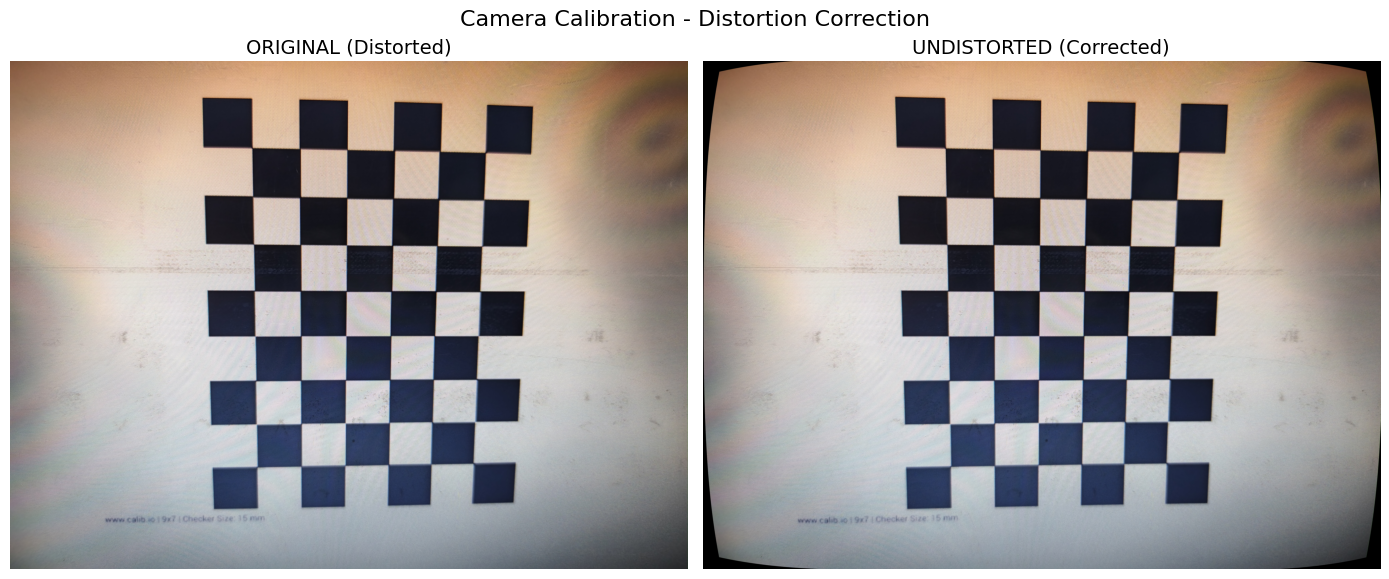

Comparison saved: calibration/undistortion_comparison.png


In [7]:
"""
Camera Calibration Script
XIS Computer Vision Assessment
Camera: Infinix Note 50
"""

import cv2
import numpy as np
import glob
import pickle
import matplotlib.pyplot as plt
import os

CHESSBOARD_SIZE = (8, 6)
SQUARE_SIZE_MM  = 15.0
IMAGES_PATH     = "calibration/images/*.jpg"
OUTPUT_PATH     = "calibration/calibration.pkl"
OUTPUT_REPORT   = "calibration/calibration_report.txt"


def calibrate_camera():

    objp = np.zeros(
        (CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32
    )
    objp[:, :2] = np.mgrid[
        0:CHESSBOARD_SIZE[0],
        0:CHESSBOARD_SIZE[1]
    ].T.reshape(-1, 2)
    objp *= SQUARE_SIZE_MM

    obj_points = []
    img_points = []

    images = glob.glob(IMAGES_PATH)

    if len(images) == 0:
        print("ERROR: No images found in calibration/images/")
        return

    print(f"Found {len(images)} calibration images")
    print("Processing...")

    successful = 0
    image_size = None

    for idx, fname in enumerate(images):
        img  = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        image_size = gray.shape[::-1]

        ret, corners = cv2.findChessboardCorners(
            gray, CHESSBOARD_SIZE, None
        )

        if ret:
            criteria = (
                cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
                30, 0.001
            )
            corners_refined = cv2.cornerSubPix(
                gray, corners, (11, 11), (-1, -1), criteria
            )
            obj_points.append(objp)
            img_points.append(corners_refined)
            successful += 1
            print(f"  Image {idx+1:02d}: SUCCESS - corners detected")
        else:
            print(f"  Image {idx+1:02d}: FAILED  - corners not found ({os.path.basename(fname)})")

    print(f"\nSuccessful: {successful}/{len(images)}")

    if successful < 5:
        print("ERROR: Need at least 5 successful images.")
        return

    print("\nRunning calibration...")
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        obj_points, img_points, image_size, None, None
    )

    total_error = 0
    for i in range(len(obj_points)):
        projected, _ = cv2.projectPoints(
            obj_points[i], rvecs[i], tvecs[i],
            camera_matrix, dist_coeffs
        )
        error = cv2.norm(
            img_points[i], projected, cv2.NORM_L2
        ) / len(projected)
        total_error += error

    reprojection_error = total_error / len(obj_points)

    if reprojection_error < 0.3:
        quality = "EXCELLENT"
    elif reprojection_error < 0.5:
        quality = "GOOD"
    elif reprojection_error < 1.0:
        quality = "ACCEPTABLE"
    else:
        quality = "POOR"

    print("\n" + "="*50)
    print("CALIBRATION RESULTS")
    print("="*50)
    print(f"Reprojection Error: {reprojection_error:.4f} px")
    print(f"Quality:            {quality}")
    print(f"\nCamera Matrix:")
    print(camera_matrix)
    print(f"\nDistortion Coefficients:")
    print(dist_coeffs)

    calibration_data = {
        "camera_matrix"     : camera_matrix,
        "dist_coeffs"       : dist_coeffs,
        "reprojection_error": reprojection_error,
        "image_size"        : image_size,
        "square_size_mm"    : SQUARE_SIZE_MM,
        "successful_images" : successful,
    }

    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

    with open(OUTPUT_PATH, "wb") as f:
        pickle.dump(calibration_data, f)
    print(f"\nCalibration saved: {OUTPUT_PATH}")

    with open(OUTPUT_REPORT, "w") as f:
        f.write("CAMERA CALIBRATION REPORT\n")
        f.write("="*50 + "\n")
        f.write(f"Camera:              Infinix Note 50\n")
        f.write(f"Checkerboard Size:   {CHESSBOARD_SIZE}\n")
        f.write(f"Square Size:         {SQUARE_SIZE_MM} mm\n")
        f.write(f"Images Used:         {successful}/{len(images)}\n")
        f.write(f"Reprojection Error:  {reprojection_error:.4f} px\n")
        f.write(f"Quality:             {quality}\n\n")
        f.write(f"Camera Matrix:\n{camera_matrix}\n\n")
        f.write(f"Distortion Coefficients:\n{dist_coeffs}\n")
    print(f"Report saved:      {OUTPUT_REPORT}")

    show_undistortion_example(images[0], camera_matrix, dist_coeffs)


def show_undistortion_example(image_path, camera_matrix, dist_coeffs):
    img         = cv2.imread(image_path)
    undistorted = cv2.undistort(img, camera_matrix, dist_coeffs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("ORIGINAL (Distorted)", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
    axes[1].set_title("UNDISTORTED (Corrected)", fontsize=14)
    axes[1].axis("off")

    plt.suptitle("Camera Calibration - Distortion Correction", fontsize=16)
    plt.tight_layout()
    os.makedirs("calibration", exist_ok=True)
    plt.savefig("calibration/undistortion_comparison.png", dpi=150)
    plt.show()
    print("Comparison saved: calibration/undistortion_comparison.png")


if __name__ == "__main__":
    calibrate_camera()